In [522]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as sco 
import seaborn as sns

In [523]:
daily_returns = pd.read_csv(
    "data/processed/daily_returns.csv",
    index_col=0,
    parse_dates=True
)

adj_close = pd.read_csv(
    "data/processed/adj_close.csv",
    index_col=0,
    parse_dates=True
)

cov_matrix = pd.read_csv(
    "data/processed/cov_matrix.csv",
    index_col=0
)

metrics_table = pd.read_csv(
    "data/processed/metrics_table.csv",
    index_col=0
)

daily_rfr = pd.read_csv(
    "data/processed/daily_risk_free_rate.csv",
    index_col = 0
)

In [524]:
from src.metrics import portfolio_return, portfolio_volatility, sharpe_ratio, negative_sharpe

In [525]:
long_returns = daily_returns.reset_index().melt(id_vars = 'Date', value_vars = daily_returns.columns)
long_returns.columns = ['Date', 'Asset','Return']
long_returns['Date'] = pd.to_datetime(long_returns['Date'])
long_returns = long_returns.sort_values(['Asset','Date'])
daily_rfr.index = pd.to_datetime(daily_rfr.index)
long_returns = long_returns.merge(
    daily_rfr,
    left_on='Date',
    right_index= True,
    how = 'left'
)
long_returns['excess_return'] = long_returns['Return'] - long_returns['daily_rfr']

In [526]:
long_adj_close = adj_close.reset_index().melt(id_vars = 'Date', value_vars = adj_close.columns).set_index('Date')
long_adj_close.columns = ['Asset','Adj_close']
long_adj_close = long_adj_close.sort_values(['Asset','Date'])
long_adj_close['log_return'] = (
    long_adj_close.groupby('Asset')['Adj_close'].transform(
        lambda x: np.log(x).diff())
    )
long_adj_close = long_adj_close.dropna(subset = ['log_return'])
long_data = long_returns.merge(
    long_adj_close,
    on = ('Date', 'Asset'),
    how = 'inner'
)
long_data['Date'] = pd.to_datetime(long_data['Date'])

## Static Optimized Portfolio - Baseline

In [527]:
## CREATING WEIGHTS ##
weight_list = (
    0.15, #AGG
    0.00, #EEM
    0.15, #EFA
    0.15, #GLD
    0.00, #IWM
    0.10, #LQD
    0.05, #MTUM
    0.15, #QQQ
    0.00, #QUAL
    0.10, #SPY
    0.00, #TLT
    0.00, #USMV
    0.15, #VLUE
    0.00  #VNQ
)
weights = {}
for i in range(len(daily_returns.columns)):
    key = daily_returns.columns[i]
    weight = weight_list[i]
    weights[key] = weight
long_data['weights'] = long_data['Asset'].map(weights)

if sum(weight_list) != 1:
    print("Does Not Equal 1")
else:
    print('Weights Equal 1')


Weights Equal 1


In [528]:
## ESTABLISHING BASELINE PERFORMANCE FOR THE INITITAL PORTFOLIO ##

long_data['weighted_returns'] = long_data['weights'] * long_data['Return']

weighted_returns_df = pd.DataFrame(long_data.groupby('Date')['weighted_returns'].sum()).reset_index()

weighted_returns_df['rolling_return'] = weighted_returns_df['weighted_returns'].rolling(21).mean()
weighted_returns_df['rolling_vol'] =  weighted_returns_df['weighted_returns'].rolling(21).std() * np.sqrt(252)

weighted_returns_df['portfolio_value'] = (
    1 + weighted_returns_df['weighted_returns']
).cumprod()
weighted_returns_df['running_peak'] = weighted_returns_df['portfolio_value'].cummax()
weighted_returns_df['drawdown'] = (
    weighted_returns_df['portfolio_value'] / weighted_returns_df['running_peak'] - 1
)


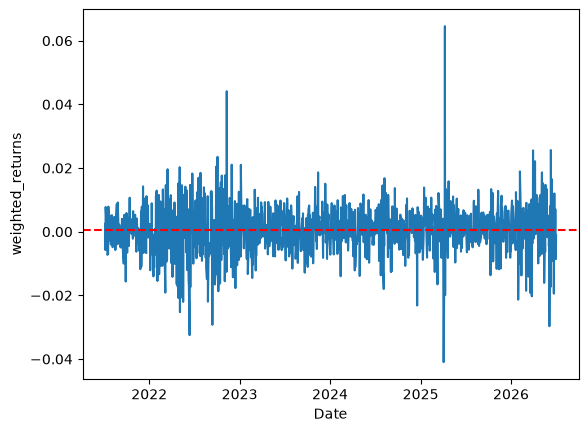

In [529]:
sns.lineplot(data = weighted_returns_df, x = 'Date', y = 'weighted_returns')
plt.axhline(y=weighted_returns_df['weighted_returns'].mean(), color='red', linestyle='--')

## Time-Based Rebalancing Strategy

In [695]:
## REBALANCING QUARTERLY BASED ON SHARPE RATIO ##
from src.config import portfolio_groups, asset_class_caps, asset_bounds
from src.optimization import build_constraints
tb_portfolio = long_data.copy()
port_start = tb_portfolio['Date'].iloc[0]
port_end = tb_portfolio['Date'].iloc[-1]

In [561]:
## Function for evaluating by date ## 
## Period Weights to be an asset indexed series of predetermined weights ##
## df will be a time-series of portfolio return data ## 
def evaluate_period(start_date, end_date, period_weights, df):
    eval_data = df[df['Date'].between(start_date, end_date)].copy()

    eval_data['weights'] = eval_data['Asset'].map(period_weights)
    eval_data['weighted_returns'] = eval_data['weights'] * eval_data['Return']
    daily_rfr = pd.Series(eval_data.groupby('Date')['daily_rfr'].mean()).values

    daily_portfolio = (
        eval_data
        .groupby('Date', as_index=False)['weighted_returns']
        .sum()
        .rename(columns={'weighted_returns': 'portfolio_return'})
    )
    daily_portfolio['rf_rate'] = daily_rfr
    daily_portfolio['portfolio_value'] = (
    1 + daily_portfolio['portfolio_return']
    ).cumprod()

    daily_portfolio['running_peak'] = daily_portfolio['portfolio_value'].cummax()

    daily_portfolio['drawdown'] = (
        daily_portfolio['portfolio_value'] / daily_portfolio['running_peak'] - 1
    )
    summary = {
        'start_date': start_date,
        'end_date': end_date,
        'period_return': daily_portfolio['portfolio_value'].iloc[-1] - 1,
        'volatility': daily_portfolio['portfolio_return'].std() * np.sqrt(252),
        'max_drawdown': daily_portfolio['drawdown'].min(),
        'avg_daily_return': daily_portfolio['portfolio_return'].mean()
    }

    return daily_portfolio, summary


In [562]:
def optimizer(df, start_date, end_date):

    opt_df = df[df['Date'].between(start_date, end_date)].copy()

    rf = opt_df['daily_rfr'].mean()

    returns = (
        opt_df.pivot(index = 'Date', columns = 'Asset', values = 'Return')
        )
    returns_mean = returns.mean()
    returns_cov = returns.cov()
    initial = np.array([1/ len(returns.columns)] * len(returns.columns))
    
    optimized = sco.minimize(
    negative_sharpe,
    initial, 
    args = (returns_mean, returns_cov, rf),
    method = "SLSQP",
    bounds = bounds,
    constraints = constraints
    )

    return pd.Series(optimized.x, index=returns.columns)

In [683]:
def build_evaluation_schedule(df, date_col='Date', lookback_obs=252, min_obs=63):
    dates = (
        pd.to_datetime(df[date_col])
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

    port_start = dates.iloc[0]
    port_end = dates.iloc[-1]

    hold_starts = pd.date_range(
        port_start.to_period('Q').start_time,
        port_end,
        freq='QS'
    )

    rows = []

    for hold_start in hold_starts:
        hold_end = hold_start + pd.offsets.QuarterEnd(0)

        if hold_start > port_end:
            continue

        hold_end = min(hold_end, port_end)

        available_est_dates = dates[dates < hold_start]

        if len(available_est_dates) < min_obs:
            continue

        est_dates = available_est_dates.tail(lookback_obs)

        rows.append({
            'est_start': est_dates.iloc[0],
            'est_end': est_dates.iloc[-1],
            'hold_start': hold_start,
            'hold_end': hold_end,
            'est_obs': len(est_dates)
        })

    return pd.DataFrame(rows)

In [691]:
evaluation_schedule = build_evaluation_schedule(
    tb_portfolio,
    date_col='Date',
    lookback_obs=252,
    min_obs=63
)

In [685]:
tickers = daily_returns.columns

constraints = build_constraints(
    tickers,
    portfolio_groups,
    asset_class_caps
)

bounds = tuple(asset_bounds for _ in range(len(tickers)))

In [694]:
weights_2021 = pd.Series(weight_list, index = daily_returns.columns)
print(f'start:{port_start}, end: {port_end}')

start:2021-07-07 00:00:00, end: 2026-07-02 00:00:00


In [712]:
## Annual Evaluation
eval_results = []

daily_2021, summary_2021 = evaluate_period(
    start_date = port_start,
    end_date = '2021-12-31',
    period_weights=weights_2021,
    df = tb_portfolio)

eval_results.append(summary_2021)

weights_2022 = optimizer(
    df = tb_portfolio, 
    start_date= port_start,
    end_date= '2021-12-31'
          )
daily_2022, summary_2022 = evaluate_period(
    start_date = '2022-01-01',
    end_date = '2022-12-31',
    period_weights=weights_2022,
    df = tb_portfolio)

eval_results.append(summary_2022)

weights_2023 = optimizer(
    df = tb_portfolio,
    start_date = port_start, 
    end_date= '2022-12-31'
)
daily_2023, summary_2023 = evaluate_period(
    start_date = '2023-01-01',
    end_date = '2023-12-31',
    period_weights=weights_2023,
    df = tb_portfolio)

eval_results.append(summary_2023)

weights_2024 = optimizer(
    df = tb_portfolio,
    start_date = port_start, 
    end_date= '2023-12-31'
)
daily_2024, summary_2024 = evaluate_period(
    start_date = '2024-01-01',
    end_date = '2024-12-31',
    period_weights=weights_2024,
    df = tb_portfolio)

eval_results.append(summary_2024)

weights_2025 = optimizer(
    df = tb_portfolio,
    start_date = port_start, 
    end_date= '2024-12-31'
)
daily_2025, summary_2025 = evaluate_period(
    start_date = '2025-01-01',
    end_date = '2025-12-31',
    period_weights=weights_2025,
    df = tb_portfolio)

eval_results.append(summary_2025)

weights_2026 = optimizer(
    df = tb_portfolio,
    start_date = port_start, 
    end_date= '2025-12-31'
)
daily_2026, summary_2026 = evaluate_period(
    start_date = '2025-01-01',
    end_date = port_end,
    period_weights=weights_2026,
    df = tb_portfolio)

eval_results.append(summary_2025)
results_df_annual = pd.DataFrame(eval_results)
annually_balanced = pd.concat([daily_2021, daily_2022, daily_2023, daily_2024, daily_2025, daily_2026])
annually_balanced['rolling_return'] = annually_balanced['portfolio_return'].rolling(21).mean()
annually_balanced['rolling_vol'] =  annually_balanced['portfolio_return'].rolling(21).std() * np.sqrt(252)

In [713]:
results_df_annual['period_return'].mean()


np.float64(0.10017321357925309)

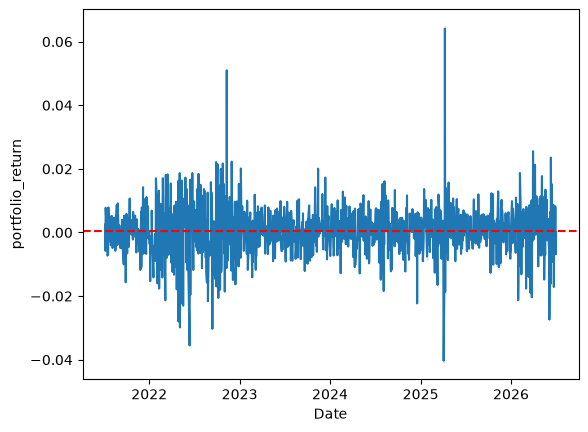

In [688]:
sns.lineplot(data = annually_balanced, x = 'Date', y = 'portfolio_return')
plt.axhline(y=annually_balanced['portfolio_return'].mean(), color='red', linestyle='--')

In [701]:
Q1_daily, Q1_summary = evaluate_period(
    start_date = port_start,
    end_date = '2021-09-30',
    period_weights=weights_2021,
    df = tb_portfolio)
eval_results_1 = []
eval_results.append(Q1_summary)
rebalanced_quarterly = Q1_daily.copy()

In [702]:
## Quarterly Evaluation ##
for _, period in evaluation_schedule.iterrows():

    weights = optimizer(
        df = tb_portfolio,
        start_date = period['est_start'],
        end_date = period['est_end']
    )

    daily, summary = evaluate_period(
    start_date = period['hold_start'],
    end_date = period['hold_end'],
    period_weights=weights,
    df = tb_portfolio
    )

    summary['est_start'] = period['est_start']
    summary['est_end'] = period['est_end']
    summary['hold_start'] = period['hold_start']
    summary['hold_end'] = period['hold_end']
    summary['est_obs'] = period['est_obs']

    eval_results.append(summary)
    rebalanced_quarterly = pd.concat([rebalanced_quarterly, daily])

results_df = pd.DataFrame(eval_results)


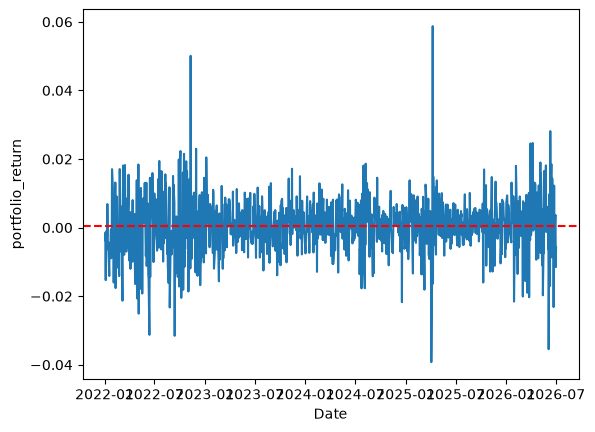

In [690]:
sns.lineplot(data = rebalanced_quarterly, x = 'Date', y = 'portfolio_return')
plt.axhline(y=rebalanced_quarterly['portfolio_return'].mean(), color='red', linestyle='--')

In [706]:
results_df['period_return'].mean()*4

np.float64(0.1564598037616871)